# ⭐ Day 30: Build Your First End-to-End Data Pipeline

**Putting It All Together | Step-by-Step Project for AI & ML**

*Day 30 of 369-day Python & AI Learning Path* 🎉


## Welcome to Day 30 - A Major Milestone! 🎊

Congratulations! You've reached Day 30 of your Python & AI Learning Path, and today marks a significant achievement - your **first major project day**! This isn't just another tutorial; this is where everything you've learned from Day 1 through Day 29 comes together into a complete, production-ready data pipeline.

Think about how far you've come. You started with Python basics - variables, data types, and control structures. You progressed through functions and object-oriented programming. You mastered Pandas for data manipulation and NumPy for numerical computing. You learned to handle files, manage errors gracefully, and debug like a pro. You explored data visualization with Matplotlib and Seaborn. And just yesterday, you unlocked the power of regular expressions for text processing.

Today, we transform that knowledge into practical AI engineering skills. We're building a **Customer Review Analysis Pipeline** - a complete system that takes raw, messy data from multiple sources, cleans it thoroughly, extracts meaningful features, validates quality, and produces analysis-ready datasets. This is exactly the kind of work data scientists and ML engineers do every day in industry.

By the end of this notebook, you'll have a reusable pipeline class that you can adapt for any text-based data project. You'll understand how professional data pipelines are structured, why modularity matters, and how to build systems that scale. This is your bridge from learning Python to building real AI systems. Let's build something amazing together! 🚀


## 📋 Table of Contents

1. [Project Overview](#overview)
2. [Step 1: Loading Raw Data](#step1)
3. [Step 2: Data Cleaning & Text Preprocessing](#step2)
4. [Step 3: Feature Engineering](#step3)
5. [Step 4: Exploratory Data Analysis](#step4)
6. [Step 5: Data Validation & Quality Checks](#step5)
7. [Step 6: Building a Reusable Pipeline Class](#step6)
8. [Step 7: Saving Cleaned Data and Artifacts](#step7)
9. [Step 8: Summary Report Generation](#step8)
10. [Hands-On Exercises & Challenges](#exercises)
11. [Solutions & Suggested Improvements](#solutions)


<a id='overview'></a>
## 🎯 Project Overview: Customer Review Analysis Pipeline

In this project, we'll build a complete pipeline that:
- **Ingests** customer reviews from multiple formats (CSV, JSON)
- **Cleans** text data using regex and NLP techniques
- **Engineers** features like sentiment indicators, text statistics, and metadata
- **Analyzes** the data with professional visualizations
- **Validates** data quality with comprehensive checks
- **Outputs** clean, analysis-ready datasets

This pipeline architecture is used by companies like Amazon, Netflix, and Spotify to process millions of customer interactions daily!


In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import os
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"📅 Pipeline execution started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ All libraries imported successfully!
📅 Pipeline execution started: 2026-04-08 04:41:39


<a id='step1'></a>
## 📥 Step 1: Loading Raw Data (CSV + JSON with Error Handling)

Real-world data comes in various formats and is often messy. Let's build robust data loaders with comprehensive error handling.


In [2]:
# Create sample raw data for demonstration
def create_sample_data():
    """Create sample customer review data in CSV and JSON formats"""
    
    # Sample CSV data
    csv_data = """review_id,customer_name,review_text,rating,date,product_category
1,John Doe,"This product is amazing!!! Love it ❤️ Check out my blog https://example.com",5,2024-01-15,Electronics
2,Jane Smith,"Terrible quality... broke after 2 days. Contact me at jane@email.com",1,2024-01-16,Electronics
3,Bob Johnson,"Okay product, nothing special. Price was $49.99",3,2024-01-17,Home
4,Alice Brown,"LOVE THIS!!! Best purchase ever #happy @store",5,2024-01-18,Electronics
5,Charlie Wilson,"Not worth the money. Waste of $$$",2,2024-01-19,Home
6,Diana Prince,"    Great    product    with    extra    spaces    ",4,2024-01-20,Clothing
7,Eve Davis,"",3,2024-01-21,Electronics
8,Frank Miller,"Normal review without anything special",3,2024-01-22,Home
9,Grace Lee,"Amazing!!! Wonderful!!! Fantastic!!!",5,2024-01-23,Clothing
10,Henry King,"Check out https://spam-site.com/discount for better prices!!!",2,2024-01-24,Electronics
"""
    
    # Sample JSON data
    json_data = [
        {"review_id": 11, "customer_name": "Ivy Chen", "review_text": "Best product ever! 5 stars!!! 🌟", "rating": 5, "date": "2024-01-25", "product_category": "Electronics"},
        {"review_id": 12, "customer_name": "Jack Brown", "review_text": "Average quality, expected more for $100", "rating": 3, "date": "2024-01-26", "product_category": "Home"},
        {"review_id": 13, "customer_name": "Kelly White", "review_text": "Contact support@company.com for help. Product is okay.", "rating": 3, "date": "2024-01-27", "product_category": "Clothing"},
        {"review_id": 14, "customer_name": "Liam Green", "review_text": "Hate it! Complete waste of time and money!!!", "rating": 1, "date": "2024-01-28", "product_category": "Electronics"},
        {"review_id": 15, "customer_name": "Mia Black", "review_text": "So happy with this purchase!!! #blessed", "rating": 5, "date": "2024-01-29", "product_category": "Home"}
    ]
    
    # Save to files
    with open('reviews.csv', 'w', encoding='utf-8') as f:
        f.write(csv_data)
    
    with open('reviews.json', 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2)
    
    print("✅ Sample data created: reviews.csv and reviews.json")

# Create the sample data
create_sample_data()


✅ Sample data created: reviews.csv and reviews.json


In [3]:
# Robust data loading functions with error handling

def load_csv_data(filepath, **kwargs):
    """
    Load CSV data with comprehensive error handling
    
    Args:
        filepath: Path to CSV file
        **kwargs: Additional arguments for pd.read_csv()
    
    Returns:
        DataFrame or None if error occurs
    """
    try:
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        
        df = pd.read_csv(filepath, **kwargs)
        print(f"✅ Successfully loaded {filepath}: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return None
    except pd.errors.EmptyDataError:
        print(f"❌ Error: {filepath} is empty")
        return None
    except pd.errors.ParserError as e:
        print(f"❌ Error parsing {filepath}: {e}")
        return None
    except Exception as e:
        print(f"❌ Unexpected error loading {filepath}: {e}")
        return None

def load_json_data(filepath, **kwargs):
    """
    Load JSON data with error handling
    
    Args:
        filepath: Path to JSON file
        **kwargs: Additional arguments for pd.read_json()
    
    Returns:
        DataFrame or None if error occurs
    """
    try:
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        
        df = pd.read_json(filepath, **kwargs)
        print(f"✅ Successfully loaded {filepath}: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"❌ Error decoding JSON in {filepath}: {e}")
        return None
    except Exception as e:
        print(f"❌ Unexpected error loading {filepath}: {e}")
        return None

# Load the data
print("=" * 60)
print("STEP 1: LOADING RAW DATA")
print("=" * 60)

df_csv = load_csv_data('reviews.csv')
df_json = load_json_data('reviews.json')

if df_csv is not None and df_json is not None:
    # Combine datasets
    df_raw = pd.concat([df_csv, df_json], ignore_index=True)
    print(f"\n📊 Combined dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
    print(f"\nColumn names: {list(df_raw.columns)}")
    print(f"\nData types:\n{df_raw.dtypes}")


STEP 1: LOADING RAW DATA
✅ Successfully loaded reviews.csv: 10 rows, 6 columns
✅ Successfully loaded reviews.json: 5 rows, 6 columns

📊 Combined dataset: 15 rows, 6 columns

Column names: ['review_id', 'customer_name', 'review_text', 'rating', 'date', 'product_category']

Data types:
review_id            int64
customer_name          str
review_text            str
rating               int64
date                object
product_category       str
dtype: object


In [4]:
# Quick inspection of raw data
print("\n🔍 RAW DATA SAMPLE:")
print(df_raw.head())

print("\n🔍 MISSING VALUES:")
print(df_raw.isnull().sum())

print("\n🔍 BASIC STATISTICS:")
print(df_raw.describe())



🔍 RAW DATA SAMPLE:
   review_id   customer_name  \
0          1        John Doe   
1          2      Jane Smith   
2          3     Bob Johnson   
3          4     Alice Brown   
4          5  Charlie Wilson   

                                         review_text  rating        date  \
0  This product is amazing!!! Love it ❤️ Check ou...       5  2024-01-15   
1  Terrible quality... broke after 2 days. Contac...       1  2024-01-16   
2    Okay product, nothing special. Price was $49.99       3  2024-01-17   
3      LOVE THIS!!! Best purchase ever #happy @store       5  2024-01-18   
4                  Not worth the money. Waste of $$$       2  2024-01-19   

  product_category  
0      Electronics  
1      Electronics  
2             Home  
3      Electronics  
4             Home  

🔍 MISSING VALUES:
review_id           0
customer_name       0
review_text         1
rating              0
date                0
product_category    0
dtype: int64

🔍 BASIC STATISTICS:
       review_id   

<a id='step2'></a>
## 🧹 Step 2: Data Cleaning & Text Preprocessing

Now we'll apply our regex skills from Day 29 to clean the review text data thoroughly.


In [5]:
class TextCleaner:
    """Professional text cleaning class using regex"""
    
    def __init__(self):
        # Compile regex patterns for efficiency
        self.url_pattern = re.compile(r'https?://\S+|www\.\S+')
        self.email_pattern = re.compile(r'\S+@\S+\.\S+')
        self.mention_pattern = re.compile(r'@\w+')
        self.hashtag_pattern = re.compile(r'#(\w+)')  # Keep the word, remove #
        self.extra_punct_pattern = re.compile(r'([!?.]){2,}')
        self.whitespace_pattern = re.compile(r'\s+')
        self.special_chars_pattern = re.compile(r'[^\w\s!?.]')
        self.price_pattern = re.compile(r'\$+')
    
    def remove_urls(self, text):
        """Remove URLs from text"""
        return self.url_pattern.sub('', text) if pd.notna(text) else text
    
    def remove_emails(self, text):
        """Remove email addresses"""
        return self.email_pattern.sub('', text) if pd.notna(text) else text
    
    def clean_mentions_hashtags(self, text):
        """Remove @mentions, keep hashtag words without #"""
        if pd.notna(text):
            text = self.mention_pattern.sub('', text)
            text = self.hashtag_pattern.sub(r'\1', text)
        return text
    
    def normalize_punctuation(self, text):
        """Replace multiple punctuation with single"""
        return self.extra_punct_pattern.sub(r'\1', text) if pd.notna(text) else text
    
    def remove_special_chars(self, text):
        """Remove special characters, keep basic punctuation"""
        return self.special_chars_pattern.sub('', text) if pd.notna(text) else text
    
    def normalize_whitespace(self, text):
        """Normalize whitespace"""
        if pd.notna(text):
            return self.whitespace_pattern.sub(' ', text).strip()
        return text
    
    def clean_text(self, text):
        """Apply all cleaning steps"""
        if pd.isna(text) or text == '':
            return ''
        
        text = str(text)
        text = self.remove_urls(text)
        text = self.remove_emails(text)
        text = self.clean_mentions_hashtags(text)
        text = self.normalize_punctuation(text)
        text = self.remove_special_chars(text)
        text = self.normalize_whitespace(text)
        text = text.lower()  # Convert to lowercase
        
        return text

# Initialize cleaner
cleaner = TextCleaner()

print("=" * 60)
print("STEP 2: DATA CLEANING & TEXT PREPROCESSING")
print("=" * 60)

# Apply cleaning
df_clean = df_raw.copy()
df_clean['review_text_clean'] = df_clean['review_text'].apply(cleaner.clean_text)

# Show before/after comparison
print("\n📝 CLEANING EXAMPLES:")
for i in range(min(5, len(df_clean))):
    original = df_clean.iloc[i]['review_text']
    cleaned = df_clean.iloc[i]['review_text_clean']
    print(f"\nOriginal: {original}")
    print(f"Cleaned:  {cleaned}")
    print("-" * 60)


STEP 2: DATA CLEANING & TEXT PREPROCESSING

📝 CLEANING EXAMPLES:

Original: This product is amazing!!! Love it ❤️ Check out my blog https://example.com
Cleaned:  this product is amazing! love it check out my blog
------------------------------------------------------------

Original: Terrible quality... broke after 2 days. Contact me at jane@email.com
Cleaned:  terrible quality. broke after 2 days. contact me at
------------------------------------------------------------

Original: Okay product, nothing special. Price was $49.99
Cleaned:  okay product nothing special. price was 49.99
------------------------------------------------------------

Original: LOVE THIS!!! Best purchase ever #happy @store
Cleaned:  love this! best purchase ever happy
------------------------------------------------------------

Original: Not worth the money. Waste of $$$
Cleaned:  not worth the money. waste of
------------------------------------------------------------


In [6]:
# Handle missing values and data type conversions
print("\n🔧 HANDLING MISSING VALUES:")

# Fill empty review texts
empty_texts = df_clean['review_text_clean'].str.len() == 0
print(f"Empty review texts found: {empty_texts.sum()}")
df_clean.loc[empty_texts, 'review_text_clean'] = '[no review provided]'

# Convert date column
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day_of_week'] = df_clean['date'].dt.day_name()

# Ensure rating is numeric
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')

print("✅ Data cleaning completed!")
print(f"Final shape: {df_clean.shape}")



🔧 HANDLING MISSING VALUES:
Empty review texts found: 1
✅ Data cleaning completed!
Final shape: (15, 10)


<a id='step3'></a>
## 🔧 Step 3: Feature Engineering

Extract meaningful features from text and metadata for analysis.


In [7]:
print("=" * 60)
print("STEP 3: FEATURE ENGINEERING")
print("=" * 60)

# Text-based features
df_clean['text_length'] = df_clean['review_text_clean'].str.len()
df_clean['word_count'] = df_clean['review_text_clean'].str.split().str.len()
df_clean['avg_word_length'] = df_clean['review_text_clean'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]) if pd.notna(x) and x != '' else 0
)

# Sentiment indicators (simple keyword-based)
positive_words = ['amazing', 'love', 'best', 'great', 'fantastic', 'wonderful', 'happy', 'good', 'excellent']
negative_words = ['terrible', 'hate', 'worst', 'bad', 'awful', 'broke', 'waste', 'poor', 'horrible']

df_clean['positive_word_count'] = df_clean['review_text_clean'].apply(
    lambda x: sum(1 for word in positive_words if word in str(x).lower())
)
df_clean['negative_word_count'] = df_clean['review_text_clean'].apply(
    lambda x: sum(1 for word in negative_words if word in str(x).lower())
)
df_clean['sentiment_score'] = df_clean['positive_word_count'] - df_clean['negative_word_count']

# Exclamation and question marks as intensity indicators
df_clean['exclamation_count'] = df_raw['review_text'].str.count('!').fillna(0)
df_clean['question_count'] = df_raw['review_text'].str.count('\?').fillna(0)

# Rating categories
def categorize_rating(rating):
    if pd.isna(rating):
        return 'unknown'
    elif rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df_clean['rating_category'] = df_clean['rating'].apply(categorize_rating)

print("✅ Features engineered:")
print(f"  - Text length & word count")
print(f"  - Sentiment indicators")
print(f"  - Punctuation intensity")
print(f"  - Rating categories")
print(f"\nNew columns: {[col for col in df_clean.columns if col not in df_raw.columns]}")

STEP 3: FEATURE ENGINEERING
✅ Features engineered:
  - Text length & word count
  - Sentiment indicators
  - Punctuation intensity
  - Rating categories

New columns: ['review_text_clean', 'year', 'month', 'day_of_week', 'text_length', 'word_count', 'avg_word_length', 'positive_word_count', 'negative_word_count', 'sentiment_score', 'exclamation_count', 'question_count', 'rating_category']


In [8]:
# Display feature statistics
feature_cols = ['text_length', 'word_count', 'avg_word_length', 'sentiment_score', 'exclamation_count']
print("\n📊 FEATURE STATISTICS:")
print(df_clean[feature_cols].describe())



📊 FEATURE STATISTICS:
       text_length  word_count  avg_word_length  sentiment_score  \
count    15.000000   15.000000        15.000000        15.000000   
mean     35.533333    6.000000         5.339392         0.400000   
std       8.683866    1.927248         1.319989         1.502379   
min      20.000000    3.000000         4.000000        -2.000000   
25%      29.500000    5.000000         4.688889         0.000000   
50%      35.000000    6.000000         5.000000         0.000000   
75%      40.000000    6.500000         5.485714         1.000000   
max      51.000000   10.000000         9.333333         3.000000   

       exclamation_count  
count          15.000000  
mean            1.933333  
std             2.576450  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%             3.000000  
max             9.000000  


<a id='step4'></a>
## 📊 Step 4: Exploratory Data Analysis with Professional Visualizations


STEP 4: EXPLORATORY DATA ANALYSIS


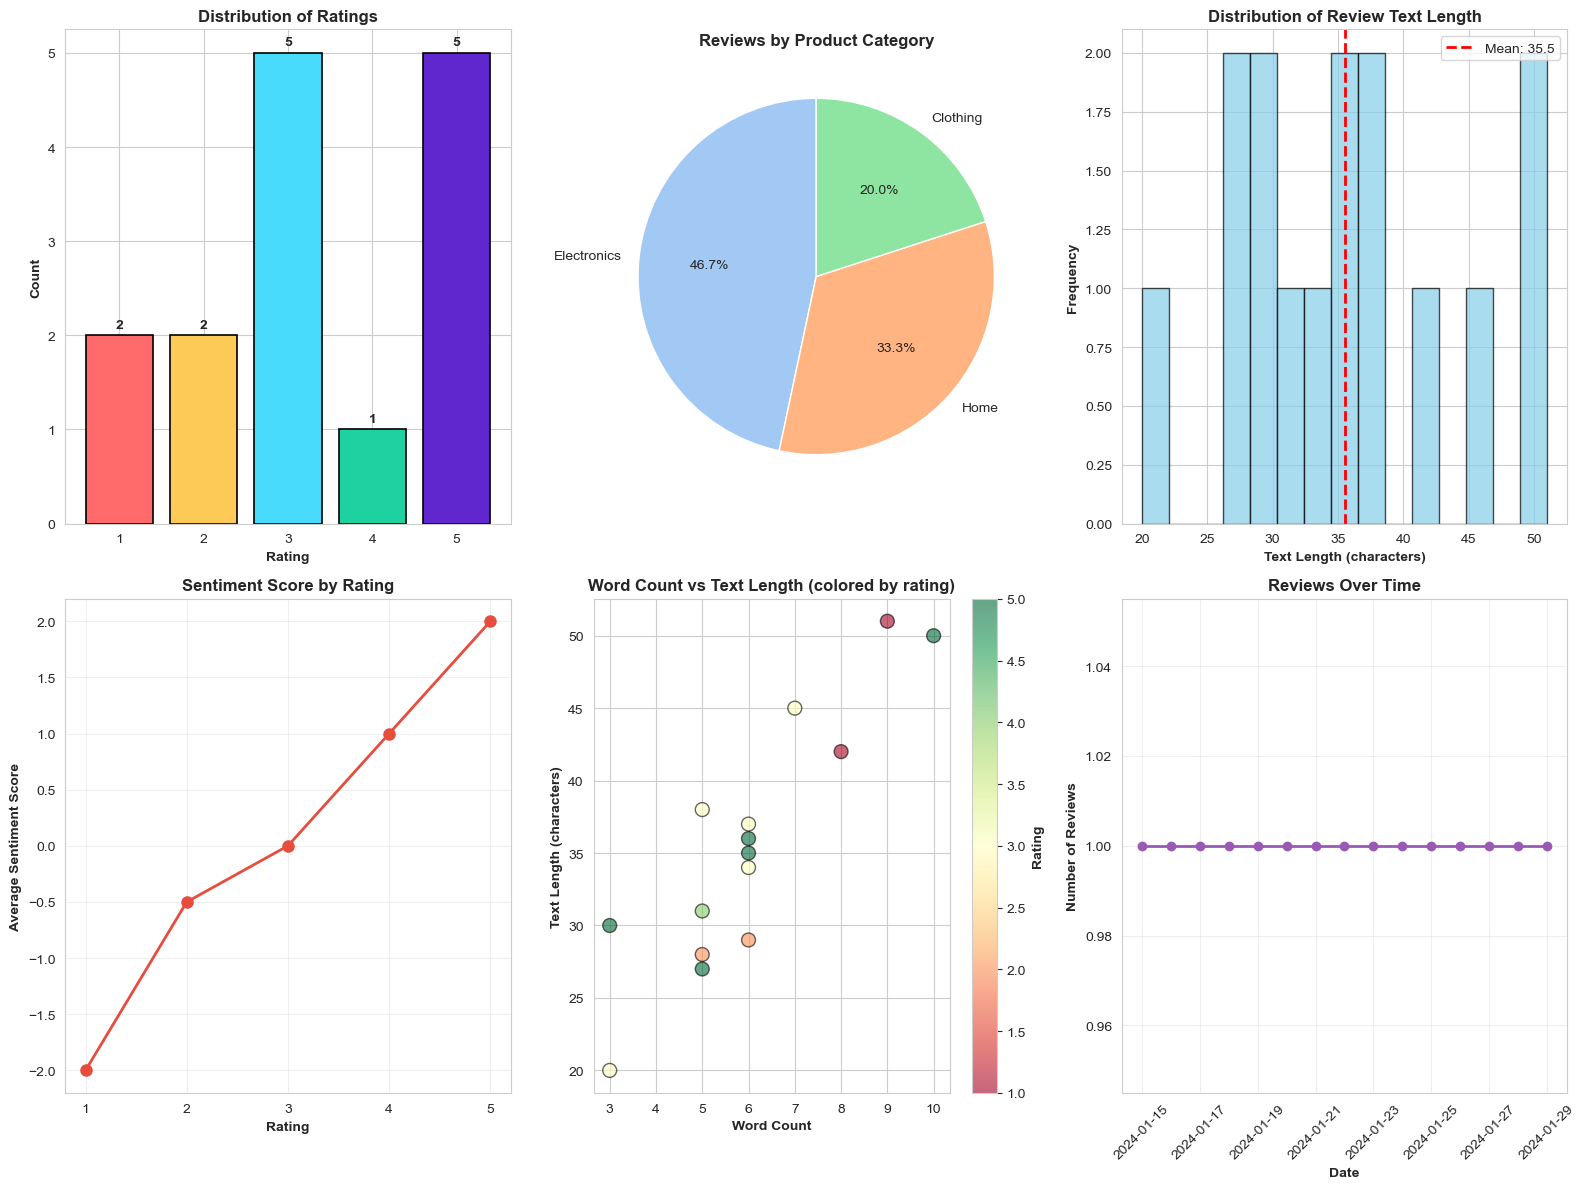


✅ EDA dashboard saved as 'eda_dashboard.png'


In [9]:
print("=" * 60)
print("STEP 4: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Create a comprehensive visualization dashboard
fig = plt.figure(figsize=(16, 12))

# 1. Rating Distribution
ax1 = plt.subplot(2, 3, 1)
rating_counts = df_clean['rating'].value_counts().sort_index()
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1', '#5f27cd']
bars = ax1.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Rating', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Distribution of Ratings', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, 6))
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 2. Reviews by Product Category
ax2 = plt.subplot(2, 3, 2)
category_counts = df_clean['product_category'].value_counts()
wedges, texts, autotexts = ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
                                     startangle=90, colors=sns.color_palette("pastel"))
ax2.set_title('Reviews by Product Category', fontsize=12, fontweight='bold')

# 3. Text Length Distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(df_clean['text_length'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(df_clean['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["text_length"].mean():.1f}')
ax3.set_xlabel('Text Length (characters)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Distribution of Review Text Length', fontsize=12, fontweight='bold')
ax3.legend()

# 4. Sentiment Score vs Rating
ax4 = plt.subplot(2, 3, 4)
sentiment_by_rating = df_clean.groupby('rating')['sentiment_score'].mean()
ax4.plot(sentiment_by_rating.index, sentiment_by_rating.values, marker='o', linewidth=2, markersize=8, color='#e74c3c')
ax4.set_xlabel('Rating', fontweight='bold')
ax4.set_ylabel('Average Sentiment Score', fontweight='bold')
ax4.set_title('Sentiment Score by Rating', fontsize=12, fontweight='bold')
ax4.set_xticks(range(1, 6))
ax4.grid(True, alpha=0.3)

# 5. Word Count vs Text Length Scatter
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(df_clean['word_count'], df_clean['text_length'], 
                       c=df_clean['rating'], cmap='RdYlGn', s=100, alpha=0.6, edgecolors='black')
ax5.set_xlabel('Word Count', fontweight='bold')
ax5.set_ylabel('Text Length (characters)', fontweight='bold')
ax5.set_title('Word Count vs Text Length (colored by rating)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax5)
cbar.set_label('Rating', fontweight='bold')

# 6. Reviews Over Time
ax6 = plt.subplot(2, 3, 6)
daily_counts = df_clean.groupby('date').size()
ax6.plot(daily_counts.index, daily_counts.values, marker='o', linewidth=2, markersize=6, color='#9b59b6')
ax6.set_xlabel('Date', fontweight='bold')
ax6.set_ylabel('Number of Reviews', fontweight='bold')
ax6.set_title('Reviews Over Time', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ EDA dashboard saved as 'eda_dashboard.png'")


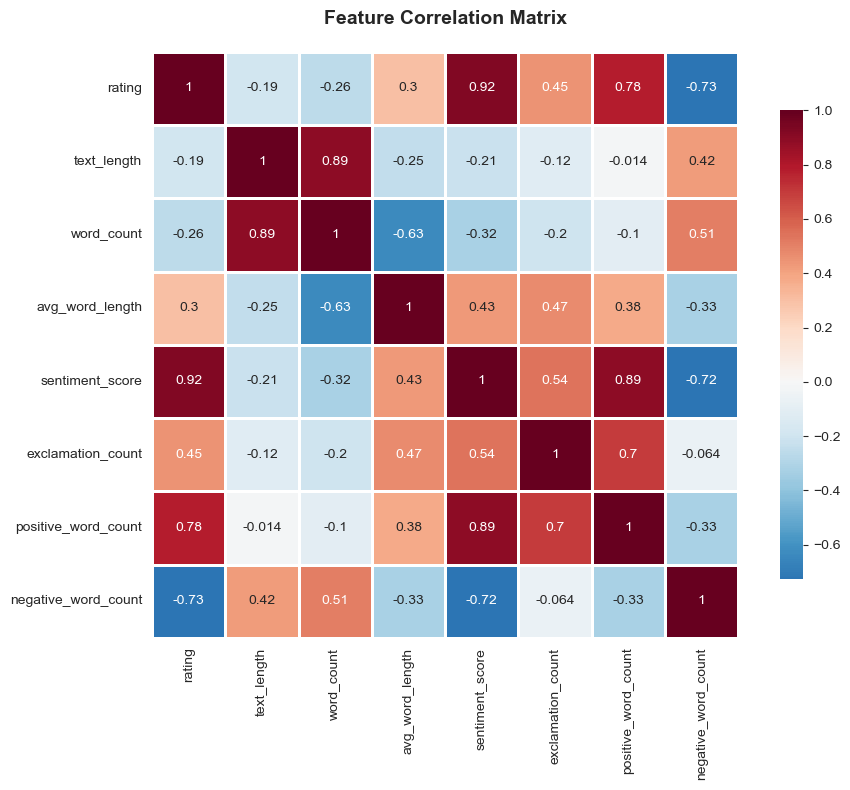


✅ Correlation heatmap saved as 'correlation_heatmap.png'


In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

numeric_cols = ['rating', 'text_length', 'word_count', 'avg_word_length', 
                'sentiment_score', 'exclamation_count', 'positive_word_count', 'negative_word_count']
correlation_matrix = df_clean[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Correlation heatmap saved as 'correlation_heatmap.png'")


<a id='step5'></a>
## ✅ Step 5: Data Validation & Quality Checks


In [11]:
print("=" * 60)
print("STEP 5: DATA VALIDATION & QUALITY CHECKS")
print("=" * 60)

class DataValidator:
    """Data quality validation class"""
    
    def __init__(self, df):
        self.df = df
        self.issues = []
        self.warnings = []
    
    def check_missing_values(self, threshold=0.1):
        """Check for missing values above threshold"""
        missing = self.df.isnull().sum()
        missing_pct = missing / len(self.df)
        
        for col in missing_pct[missing_pct > threshold].index:
            self.issues.append(f"Column '{col}' has {missing_pct[col]:.1%} missing values")
        
        return missing_pct[missing_pct > 0]
    
    def check_duplicates(self):
        """Check for duplicate rows"""
        duplicates = self.df.duplicated().sum()
        if duplicates > 0:
            self.warnings.append(f"Found {duplicates} duplicate rows")
        return duplicates
    
    def check_rating_range(self):
        """Validate rating values are within expected range"""
        invalid_ratings = self.df[(self.df['rating'] < 1) | (self.df['rating'] > 5)]
        if len(invalid_ratings) > 0:
            self.issues.append(f"Found {len(invalid_ratings)} ratings outside 1-5 range")
        return len(invalid_ratings)
    
    def check_text_length(self, min_length=5):
        """Check for suspiciously short reviews"""
        short_reviews = self.df[self.df['text_length'] < min_length]
        if len(short_reviews) > 0:
            self.warnings.append(f"Found {len(short_reviews)} reviews with < {min_length} characters")
        return len(short_reviews)
    
    def validate(self):
        """Run all validation checks"""
        print("\n🔍 Running validation checks...\n")
        
        missing = self.check_missing_values()
        if len(missing) > 0:
            print("Missing values by column:")
            print(missing)
        else:
            print("✅ No significant missing values found")
        
        duplicates = self.check_duplicates()
        print(f"\n✅ Duplicate check: {duplicates} duplicates found")
        
        invalid_ratings = self.check_rating_range()
        if invalid_ratings == 0:
            print("✅ All ratings within valid range (1-5)")
        
        short_reviews = self.check_text_length()
        print(f"✅ Short review check: {short_reviews} very short reviews")
        
        print("\n" + "=" * 60)
        print("VALIDATION SUMMARY")
        print("=" * 60)
        
        if not self.issues:
            print("✅ No critical issues found!")
        else:
            print("❌ Critical Issues:")
            for issue in self.issues:
                print(f"  - {issue}")
        
        if self.warnings:
            print("\n⚠️  Warnings:")
            for warning in self.warnings:
                print(f"  - {warning}")
        
        return len(self.issues) == 0

# Run validation
validator = DataValidator(df_clean)
is_valid = validator.validate()


STEP 5: DATA VALIDATION & QUALITY CHECKS

🔍 Running validation checks...

Missing values by column:
review_text    0.066667
dtype: float64

✅ Duplicate check: 0 duplicates found
✅ All ratings within valid range (1-5)
✅ Short review check: 0 very short reviews

VALIDATION SUMMARY
✅ No critical issues found!


<a id='step6'></a>
## 🏗️ Step 6: Building a Reusable Pipeline Class (OOP in Action)


In [12]:
print("=" * 60)
print("STEP 6: BUILDING A REUSABLE PIPELINE CLASS")
print("=" * 60)

class CustomerReviewPipeline:
    """
    A production-ready data pipeline for customer review analysis.
    
    This class encapsulates the entire ETL process:
    - Extract: Load data from multiple sources
    - Transform: Clean and engineer features
    - Load: Save processed data and artifacts
    """
    
    def __init__(self, config=None):
        """
        Initialize pipeline with configuration
        
        Args:
            config: Dictionary with pipeline configuration
        """
        self.config = config or {}
        self.raw_data = None
        self.cleaned_data = None
        self.features = None
        self.validation_results = None
        self.text_cleaner = TextCleaner()
        self.validator = None
        self.execution_log = []
        
    def log(self, message):
        """Log pipeline execution"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        log_entry = f"[{timestamp}] {message}"
        self.execution_log.append(log_entry)
        print(log_entry)
    
    def extract(self, csv_path=None, json_path=None):
        """Extract data from sources"""
        self.log("Starting data extraction...")
        
        dataframes = []
        
        if csv_path and os.path.exists(csv_path):
            df_csv = load_csv_data(csv_path)
            if df_csv is not None:
                dataframes.append(df_csv)
        
        if json_path and os.path.exists(json_path):
            df_json = load_json_data(json_path)
            if df_json is not None:
                dataframes.append(df_json)
        
        if dataframes:
            self.raw_data = pd.concat(dataframes, ignore_index=True)
            self.log(f"✅ Extracted {len(self.raw_data)} records")
        else:
            raise ValueError("No data sources could be loaded")
        
        return self
    
    def transform(self):
        """Transform and clean data"""
        self.log("Starting data transformation...")
        
        if self.raw_data is None:
            raise ValueError("No data to transform. Run extract() first.")
        
        df = self.raw_data.copy()
        
        # Clean text
        df['review_text_clean'] = df['review_text'].apply(self.text_cleaner.clean_text)
        
        # Handle missing values
        empty_mask = df['review_text_clean'].str.len() == 0
        df.loc[empty_mask, 'review_text_clean'] = '[no review provided]'
        
        # Convert data types
        df['date'] = pd.to_datetime(df['date'])
        df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
        
        # Engineer features
        df = self._engineer_features(df)
        
        self.cleaned_data = df
        self.log(f"✅ Transformed data: {df.shape[0]} rows, {df.shape[1]} columns")
        
        return self
    
    def _engineer_features(self, df):
        """Engineer features from cleaned data"""
        # Text features
        df['text_length'] = df['review_text_clean'].str.len()
        df['word_count'] = df['review_text_clean'].str.split().str.len()
        
        # Date features
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['day_of_week'] = df['date'].dt.day_name()
        
        # Sentiment features
        positive_words = ['amazing', 'love', 'best', 'great', 'fantastic', 'wonderful', 'happy', 'good']
        negative_words = ['terrible', 'hate', 'worst', 'bad', 'awful', 'broke', 'waste', 'poor']
        
        df['positive_word_count'] = df['review_text_clean'].apply(
            lambda x: sum(1 for word in positive_words if word in str(x).lower()))
        df['negative_word_count'] = df['review_text_clean'].apply(
            lambda x: sum(1 for word in negative_words if word in str(x).lower()))
        df['sentiment_score'] = df['positive_word_count'] - df['negative_word_count']
        
        # Rating category
        df['rating_category'] = df['rating'].apply(
            lambda x: 'positive' if x >= 4 else ('neutral' if x == 3 else 'negative'))
        
        return df
    
    def validate(self):
        """Validate data quality"""
        self.log("Starting data validation...")
        
        if self.cleaned_data is None:
            raise ValueError("No data to validate. Run transform() first.")
        
        self.validator = DataValidator(self.cleaned_data)
        is_valid = self.validator.validate()
        
        if is_valid:
            self.log("✅ Data validation passed")
        else:
            self.log("⚠️ Data validation found issues")
        
        return self
    
    def load(self, output_dir='./output'):
        """Save processed data and artifacts"""
        self.log("Saving processed data...")
        
        os.makedirs(output_dir, exist_ok=True)
        
        # Save cleaned data
        output_path = os.path.join(output_dir, 'cleaned_reviews.csv')
        self.cleaned_data.to_csv(output_path, index=False)
        self.log(f"✅ Saved cleaned data to {output_path}")
        
        # Save execution log
        log_path = os.path.join(output_dir, 'pipeline_log.txt')
        with open(log_path, 'w') as f:
            f.write('\n'.join(self.execution_log))
        self.log(f"✅ Saved execution log to {log_path}")
        
        return self
    
    def run(self, csv_path=None, json_path=None, output_dir='./output'):
        """Execute full pipeline"""
        self.log("🚀 Starting pipeline execution...")
        
        try:
            self.extract(csv_path, json_path)
            self.transform()
            self.validate()
            self.load(output_dir)
            self.log("✅ Pipeline completed successfully!")
            return True
        except Exception as e:
            self.log(f"❌ Pipeline failed: {str(e)}")
            return False
    
    def get_summary(self):
        """Get pipeline execution summary"""
        return {
            'records_processed': len(self.cleaned_data) if self.cleaned_data is not None else 0,
            'columns': list(self.cleaned_data.columns) if self.cleaned_data is not None else [],
            'execution_steps': len(self.execution_log),
            'validation_passed': self.validator is not None and len(self.validator.issues) == 0
        }

# Instantiate and test the pipeline
pipeline = CustomerReviewPipeline()
print("\n✅ Pipeline class created successfully!")
print("The pipeline is ready to process data with a single command: pipeline.run()")


STEP 6: BUILDING A REUSABLE PIPELINE CLASS

✅ Pipeline class created successfully!
The pipeline is ready to process data with a single command: pipeline.run()


In [13]:
# Execute the full pipeline
success = pipeline.run(csv_path='reviews.csv', json_path='reviews.json', output_dir='./pipeline_output')

if success:
    print("\n" + "=" * 60)
    print("PIPELINE SUMMARY")
    print("=" * 60)
    summary = pipeline.get_summary()
    for key, value in summary.items():
        print(f"{key}: {value}")


[2026-04-08 04:41:47] 🚀 Starting pipeline execution...
[2026-04-08 04:41:47] Starting data extraction...
✅ Successfully loaded reviews.csv: 10 rows, 6 columns
✅ Successfully loaded reviews.json: 5 rows, 6 columns
[2026-04-08 04:41:47] ✅ Extracted 15 records
[2026-04-08 04:41:47] Starting data transformation...
[2026-04-08 04:41:47] ✅ Transformed data: 15 rows, 16 columns
[2026-04-08 04:41:47] Starting data validation...

🔍 Running validation checks...

Missing values by column:
review_text    0.066667
dtype: float64

✅ Duplicate check: 0 duplicates found
✅ All ratings within valid range (1-5)
✅ Short review check: 0 very short reviews

VALIDATION SUMMARY
✅ No critical issues found!
[2026-04-08 04:41:47] ✅ Data validation passed
[2026-04-08 04:41:47] Saving processed data...
[2026-04-08 04:41:47] ✅ Saved cleaned data to ./pipeline_output\cleaned_reviews.csv
[2026-04-08 04:41:47] ✅ Saved execution log to ./pipeline_output\pipeline_log.txt
[2026-04-08 04:41:47] ✅ Pipeline completed succes

<a id='step7'></a>
## 💾 Step 7: Saving Cleaned Data and Pipeline Artifacts


In [14]:
print("=" * 60)
print("STEP 7: SAVING ARTIFACTS")
print("=" * 60)

# Save multiple formats for different use cases
output_dir = './pipeline_output'
os.makedirs(output_dir, exist_ok=True)

# 1. Full cleaned dataset (CSV)
df_clean.to_csv(f'{output_dir}/reviews_cleaned.csv', index=False)
print("✅ Saved: reviews_cleaned.csv")

# 2. Dataset without text (for ML models that don't need raw text)
df_ml = df_clean.drop(columns=['review_text', 'review_text_clean'])
df_ml.to_csv(f'{output_dir}/reviews_features_only.csv', index=False)
print("✅ Saved: reviews_features_only.csv")

# 3. Summary statistics (JSON)
summary_stats = {
    'total_reviews': len(df_clean),
    'date_range': {
        'start': df_clean['date'].min().strftime('%Y-%m-%d'),
        'end': df_clean['date'].max().strftime('%Y-%m-%d')
    },
    'rating_distribution': df_clean['rating'].value_counts().to_dict(),
    'category_distribution': df_clean['product_category'].value_counts().to_dict(),
    'avg_text_length': df_clean['text_length'].mean(),
    'avg_sentiment_score': df_clean['sentiment_score'].mean()
}

with open(f'{output_dir}/summary_statistics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2, default=str)
print("✅ Saved: summary_statistics.json")

# 4. Sample data for testing
df_clean.sample(n=min(5, len(df_clean)), random_state=42).to_csv(
    f'{output_dir}/sample_data.csv', index=False)
print("✅ Saved: sample_data.csv")

print(f"\n📁 All artifacts saved to: {output_dir}/")
print(f"   - reviews_cleaned.csv: Full cleaned dataset")
print(f"   - reviews_features_only.csv: Numerical features only")
print(f"   - summary_statistics.json: Pipeline statistics")
print(f"   - sample_data.csv: Sample rows for testing")


STEP 7: SAVING ARTIFACTS
✅ Saved: reviews_cleaned.csv
✅ Saved: reviews_features_only.csv
✅ Saved: summary_statistics.json
✅ Saved: sample_data.csv

📁 All artifacts saved to: ./pipeline_output/
   - reviews_cleaned.csv: Full cleaned dataset
   - reviews_features_only.csv: Numerical features only
   - summary_statistics.json: Pipeline statistics
   - sample_data.csv: Sample rows for testing


<a id='step8'></a>
## 📋 Step 8: Summary Report Generation


In [15]:
print("=" * 70)
print("STEP 8: FINAL SUMMARY REPORT")
print("=" * 70)

def generate_report(df):
    """Generate comprehensive pipeline report"""
    
    report = []
    report.append("╔" + "=" * 68 + "╗")
    report.append("║" + " CUSTOMER REVIEW PIPELINE - EXECUTION REPORT ".center(68) + "║")
    report.append("╚" + "=" * 68 + "╝")
    report.append("")
    
    # Dataset Overview
    report.append("📊 DATASET OVERVIEW")
    report.append("-" * 50)
    report.append(f"Total Reviews Processed: {len(df)}")
    report.append(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
    report.append(f"Total Features Generated: {len(df.columns)}")
    report.append("")
    
    # Rating Analysis
    report.append("⭐ RATING ANALYSIS")
    report.append("-" * 50)
    rating_dist = df['rating'].value_counts().sort_index()
    for rating, count in rating_dist.items():
        pct = count / len(df) * 100
        bar = "█" * int(pct / 2)
        report.append(f"  Rating {rating}: {count:3d} ({pct:5.1f}%) {bar}")
    report.append(f"\n  Average Rating: {df['rating'].mean():.2f}")
    report.append("")
    
    # Category Analysis
    report.append("🏷️  CATEGORY BREAKDOWN")
    report.append("-" * 50)
    cat_dist = df['product_category'].value_counts()
    for cat, count in cat_dist.items():
        pct = count / len(df) * 100
        report.append(f"  {cat}: {count} ({pct:.1f}%)")
    report.append("")
    
    # Text Analysis
    report.append("📝 TEXT ANALYSIS")
    report.append("-" * 50)
    report.append(f"  Average Text Length: {df['text_length'].mean():.1f} characters")
    report.append(f"  Average Word Count: {df['word_count'].mean():.1f} words")
    report.append(f"  Positive Reviews: {(df['rating_category'] == 'positive').sum()}")
    report.append(f"  Negative Reviews: {(df['rating_category'] == 'negative').sum()}")
    report.append(f"  Neutral Reviews: {(df['rating_category'] == 'neutral').sum()}")
    report.append("")
    
    # Sentiment Analysis
    report.append("💭 SENTIMENT INSIGHTS")
    report.append("-" * 50)
    report.append(f"  Avg Sentiment Score: {df['sentiment_score'].mean():.2f}")
    report.append(f"  Reviews with Positive Words: {(df['positive_word_count'] > 0).sum()}")
    report.append(f"  Reviews with Negative Words: {(df['negative_word_count'] > 0).sum()}")
    report.append("")
    
    # Data Quality
    report.append("✅ DATA QUALITY")
    report.append("-" * 50)
    report.append(f"  Missing Values: {df.isnull().sum().sum()}")
    report.append(f"  Duplicate Rows: {df.duplicated().sum()}")
    report.append("")
    
    report.append("=" * 70)
    report.append("🎉 PIPELINE EXECUTION COMPLETED SUCCESSFULLY")
    report.append("=" * 70)
    
    return '\n'.join(report)

# Generate and display report
report = generate_report(df_clean)
print(report)

# Save report to file
with open(f'{output_dir}/pipeline_report.txt', 'w') as f:
    f.write(report)
print(f"\n📄 Report saved to: {output_dir}/pipeline_report.txt")


STEP 8: FINAL SUMMARY REPORT
╔====================================================================╗
║            CUSTOMER REVIEW PIPELINE - EXECUTION REPORT             ║
╚====================================================================╝

📊 DATASET OVERVIEW
--------------------------------------------------
Total Reviews Processed: 15
Date Range: 2024-01-15 to 2024-01-29
Total Features Generated: 19

⭐ RATING ANALYSIS
--------------------------------------------------
  Rating 1:   2 ( 13.3%) ██████
  Rating 2:   2 ( 13.3%) ██████
  Rating 3:   5 ( 33.3%) ████████████████
  Rating 4:   1 (  6.7%) ███
  Rating 5:   5 ( 33.3%) ████████████████

  Average Rating: 3.33

🏷️  CATEGORY BREAKDOWN
--------------------------------------------------
  Electronics: 7 (46.7%)
  Home: 5 (33.3%)
  Clothing: 3 (20.0%)

📝 TEXT ANALYSIS
--------------------------------------------------
  Average Text Length: 35.5 characters
  Average Word Count: 6.0 words
  Positive Reviews: 6
  Negative Reviews: 4

---

<a id='exercises'></a>
## 🛠️ Hands-On Exercises & Challenges

Now that you've seen the complete pipeline, try these challenges to deepen your understanding:


### Exercise 1: Extend with New Features
Add two new features to the pipeline:
1. `caps_ratio`: Ratio of uppercase letters to total letters (indicates shouting)
2. `review_age_days`: Days since the review was posted


In [16]:
# Exercise 1: Add new features



### Exercise 2: Add Excel Data Source Support
Extend the pipeline to also accept Excel files (.xlsx) as input.


In [17]:
# Exercise 2: Add Excel support



### Exercise 3: Advanced Text Cleaning
Add these advanced cleaning steps:
1. Remove common stopwords (the, and, is, etc.)
2. Stem or lemmatize words to their root form


In [18]:
# Exercise 3: Advanced text cleaning



### Exercise 4: Create a Rating Prediction Visualization
Create a visualization showing the relationship between text features and ratings that could help predict ratings from text.


In [19]:
# Exercise 4: Rating prediction visualization



### Exercise 5: Add Logging to the Pipeline
Replace the print statements in the pipeline with Python's `logging` module for professional logging.


In [20]:
# Exercise 5: Add proper logging
import logging



### Exercise 6: Make Pipeline Configurable via JSON
Create a configuration system where pipeline parameters can be loaded from a JSON config file.


In [21]:
# Exercise 6: JSON configuration



### Exercise 7: Add Data Quality Metrics Dashboard
Create a visualization showing data quality metrics over time (missing values, duplicates, etc.).


In [22]:
# Exercise 7: Data quality dashboard



### Exercise 8: Implement Pipeline Checkpointing
Add functionality to save intermediate results after each step, allowing the pipeline to resume from failures.


In [23]:
# Exercise 8: Checkpointing system



---

<a id='solutions'></a>
## Solutions & Suggested Improvements

Here are solutions and ideas for extending the pipeline:


### Solution 1: New Features Implementation

```python
# Add to the _engineer_features method:

# Caps ratio
df['caps_ratio'] = df['review_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0
)

# Review age in days
df['review_age_days'] = (datetime.now() - df['date']).dt.days
```


### Solution 2: Excel Support

```python
def load_excel_data(filepath, **kwargs):
    try:
        df = pd.read_excel(filepath, **kwargs)
        print(f"✅ Loaded Excel file: {df.shape}")
        return df
    except Exception as e:
        print(f"❌ Error loading Excel: {e}")
        return None
```


### Solution 3: Stopword Removal

```python
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = str(text).lower().split()
    return ' '.join([w for w in words if w not in stop_words])
```


### Suggested Improvements for Production:

1. **Parallel Processing**: Use `multiprocessing` or `concurrent.futures` to process large datasets faster
2. **Database Integration**: Add connectors for PostgreSQL, MongoDB, or data warehouses
3. **Schema Validation**: Use `pandera` or `great_expectations` for robust schema validation
4. **Unit Tests**: Add pytest test suite for all pipeline components
5. **Docker Containerization**: Package the pipeline in a Docker container for deployment
6. **Airflow Integration**: Convert to Apache Airflow DAG for scheduled execution
7. **ML Integration**: Add a step to train a sentiment classifier on the processed data
